In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# loading the diabetes dataset to a pandas DataFrame
df= pd.read_csv('diabetes.csv')

In [ ]:
# Check the first few rows
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


# Check for Missing Values

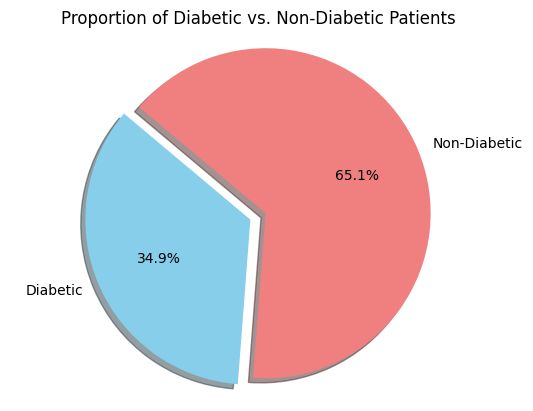

In [ ]:
# prompt: draw a pie chaRT for diabetic vs non-diabetic patients

# Pie chart for diabetic vs non-diabetic patients
import matplotlib.pyplot as plt
diabetic_patients = df['Outcome'].value_counts()[1]
non_diabetic_patients = df['Outcome'].value_counts()[0]

labels = ['Diabetic', 'Non-Diabetic']
sizes = [diabetic_patients, non_diabetic_patients]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice

# Plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Proportion of Diabetic vs. Non-Diabetic Patients')
plt.show()

In [ ]:
 df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
#Splitting the dataset into features and target variable
X = df.drop('Outcome', axis=1)
y = df['Outcome']

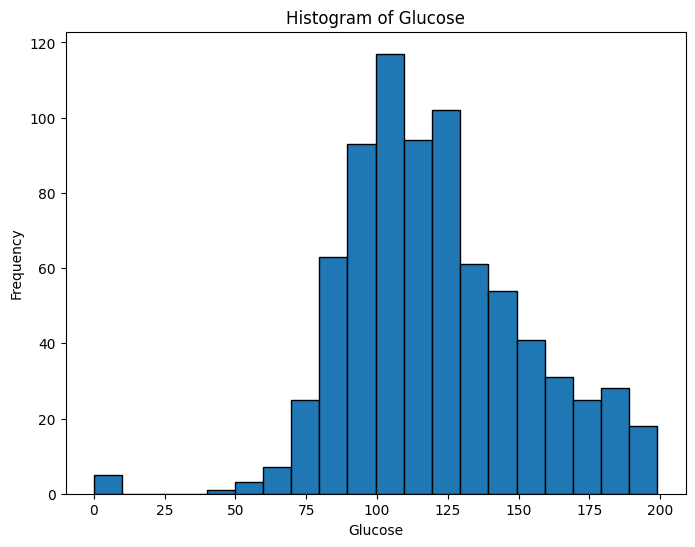

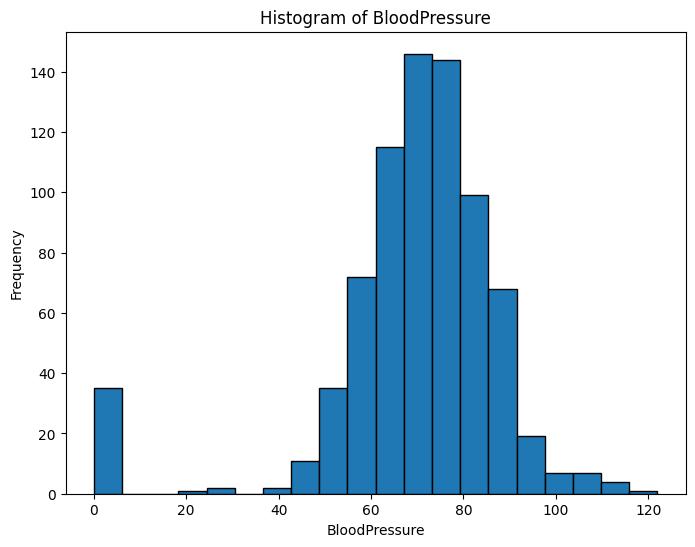

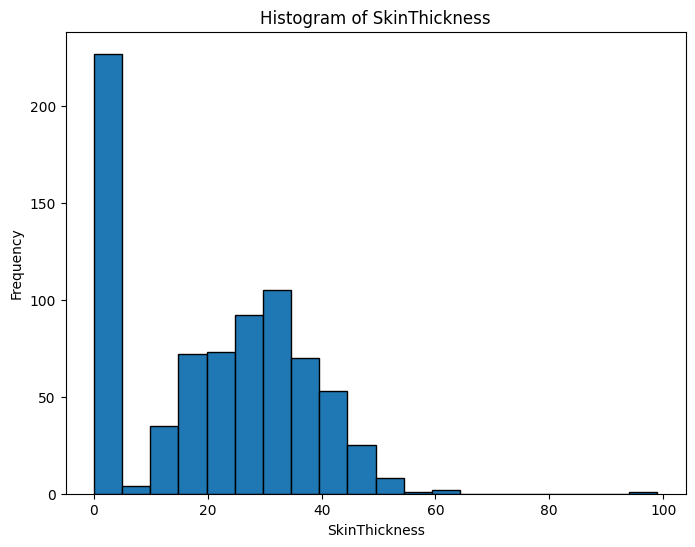

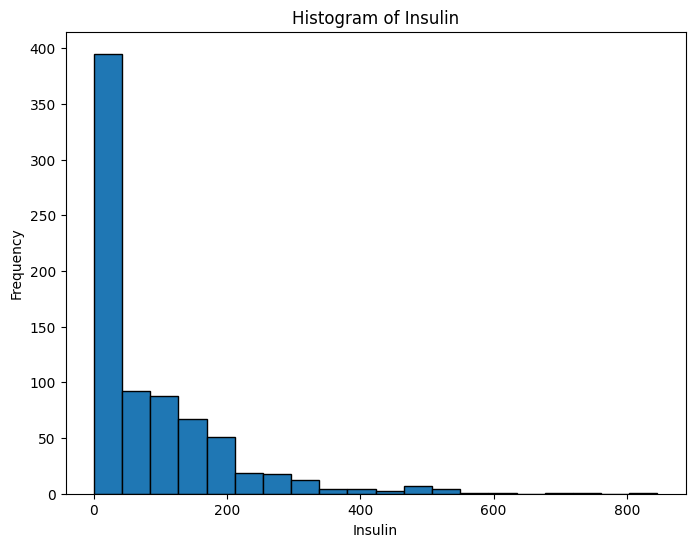

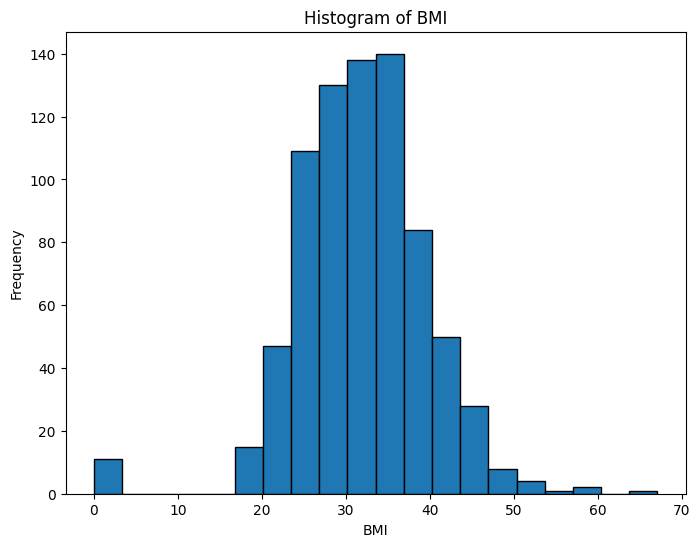

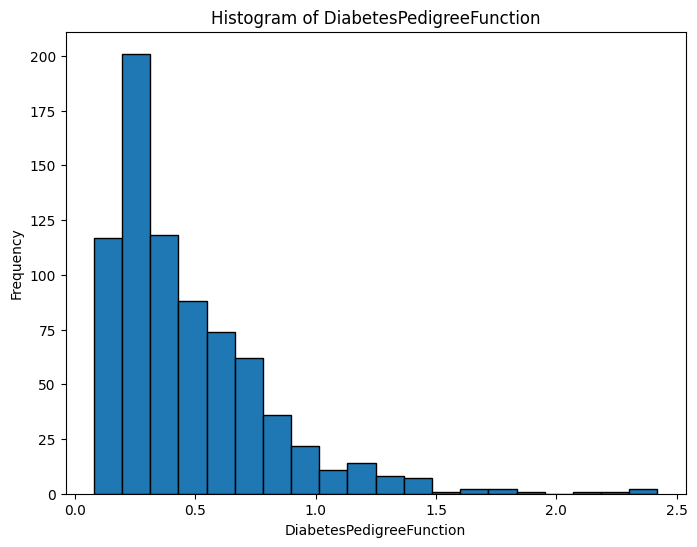

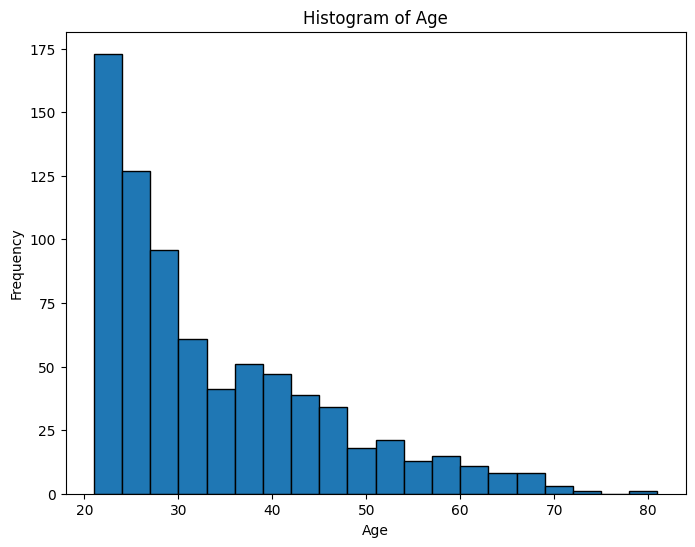

In [ ]:
import matplotlib.pyplot as plt
# Select the features you want to plot histograms for
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Create histograms for each selected feature
for feature in features:
  plt.figure(figsize=(8, 6))  # Adjust figure size if needed
  plt.hist(df[feature], bins=20, edgecolor='black')  # Adjust bins as needed
  plt.title(f'Histogram of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')
  plt.show()

Text(0.5, 1.05, 'Pearson correlation of Features')

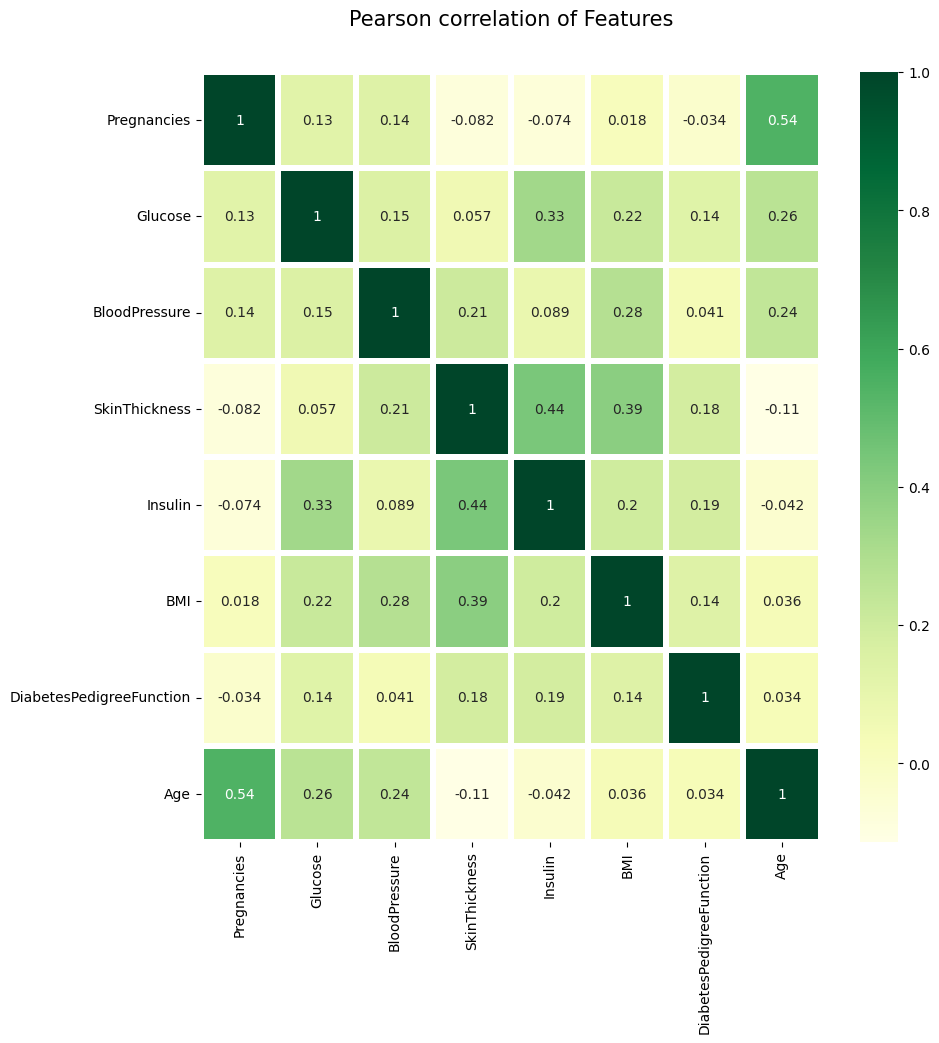

In [ ]:
import seaborn as sns
corr = df.corr(numeric_only=True)
import seaborn as sns
import matplotlib.pyplot as plt
excluded_outcome = df.drop('Outcome', axis=1)
corr = excluded_outcome.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corr, ax=ax, annot=True,linewidths=3,cmap='YlGn')
plt.title("Pearson correlation of Features", y=1.05, size=15)

In [ ]:
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Importing machine learning models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# For ensemble techniques
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, VotingClassifier

In [ ]:
#Splitting the data into train and test sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Importing StandardScaler

# Assuming 'X' contains your features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Scaling the features

# Now you can split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# K-Fold Cross-Validation

In [ ]:
svm = SVC(probability=True)
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
log_reg = LogisticRegression(max_iter=200)
xgb = XGBClassifier (eval_metric='logloss')
decision_tree = DecisionTreeClassifier(max_depth=10, min_samples_split=5, min_samples_leaf=2)


In [ ]:


# Stratified K-Fold Cross-Validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for each model
svm_scores = cross_val_score(svm, X_train, y_train, cv=skf, scoring='accuracy')
rf_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
knn_scores = cross_val_score(knn, X_train, y_train, cv=skf, scoring='accuracy')
log_reg_scores = cross_val_score(log_reg, X_train, y_train, cv=skf, scoring='accuracy')
xgb_scores = cross_val_score(xgb, X_train, y_train, cv=skf, scoring='accuracy')
decision_tree_scores = cross_val_score(decision_tree, X_train, y_train, cv=skf, scoring='accuracy')

# Print the cross-validation accuracy for each model
print(f"SVM Cross-Validation Accuracy: {svm_scores.mean():.4f}")
print(f"Random Forest Cross-Validation Accuracy: {rf_scores.mean():.4f}")
print(f"KNN Cross-Validation Accuracy: {knn_scores.mean():.4f}")
print(f"Logistic Regression Cross-Validation Accuracy: {log_reg_scores.mean():.4f}")
print(f"XGBoost Cross-Validation Accuracy: {xgb_scores.mean():.4f}")
print(f"Decision Tree Cross-Validation Accuracy: {decision_tree_scores.mean():.4f}")



SVM Cross-Validation Accuracy: 0.7638
Random Forest Cross-Validation Accuracy: 0.7639
KNN Cross-Validation Accuracy: 0.7475
Logistic Regression Cross-Validation Accuracy: 0.7654
XGBoost Cross-Validation Accuracy: 0.7444
Decision Tree Cross-Validation Accuracy: 0.7134


# Hyperparameter Tuning

In [ ]:
#Logistic Regression Tuning
param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
# Instead of passing StratifiedKFold directly, create an instance of it
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_lr.fit(X_train, y_train)
print(f"Best Params for Logistic Regression: {grid_lr.best_params_}")
print(f"Best Score for Logistic Regression: {grid_lr.best_score_:.4f}")


Best Params for Logistic Regression: {'C': 1, 'solver': 'liblinear'}
Best Score for Logistic Regression: 0.7687


In [ ]:
#Random Forest Tuning
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [10, 15, 20]}
# Instead of passing StratifiedKFold directly, create an instance of it
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_rf.fit(X_train, y_train)
print(f"Best Params for Random Forest: {grid_rf.best_params_}")
print(f"Best Score for Random Forest: {grid_rf.best_score_:.4f}")


Best Params for Random Forest: {'max_depth': 10, 'n_estimators': 100}
Best Score for Random Forest: 0.7720


In [ ]:
#SVM Tuning
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
# Create an instance of StratifiedKFold
grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_svm.fit(X_train, y_train)
print(f"Best Params for SVM: {grid_svm.best_params_}")
print(f"Best Score for SVM: {grid_svm.best_score_:.4f}")


Best Params for SVM: {'C': 1, 'kernel': 'linear'}
Best Score for SVM: 0.7703


In [ ]:
#KNN Tuning
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'metric': ['euclidean', 'manhattan']}
# Create an instance of StratifiedKFold with desired parameters
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_knn.fit(X_train, y_train)
print(f"Best Params for KNN: {grid_knn.best_params_}")
print(f"Best Score for KNN: {grid_knn.best_score_:.4f}")

Best Params for KNN: {'metric': 'euclidean', 'n_neighbors': 9}
Best Score for KNN: 0.7589


In [ ]:
#XGBoost Tuning
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
# Create an instance of StratifiedKFold with desired parameters
grid_xgb = GridSearchCV(XGBClassifier(eval_metric='mlogloss'), param_grid_xgb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_xgb.fit(X_train, y_train)
print(f"Best Params for XGBoost: {grid_xgb.best_params_}")
print(f"Best Score for XGBoost: {grid_xgb.best_score_:.4f}")


Best Params for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best Score for XGBoost: 0.7639


In [ ]:
param_grid_dt = {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 5]}
# Instead of kfold, create a StratifiedKFold instance
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Define kfold with StratifiedKFold
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=kfold, scoring='accuracy')
grid_dt.fit(X_train, y_train)
print(f"Best Params for Decision Tree: {grid_dt.best_params_}")
print(f"Best Score for Decision Tree: {grid_dt.best_score_:.4f}")

Best Params for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Score for Decision Tree: 0.7508


# Training Various Models

In [ ]:
training_accuracy = []
testing_accuracy = []
model_name = []
precision = []
recall = []
f1 = []
roc_auc = []

Logistic Regression Test Accuracy: 0.6948051948051948


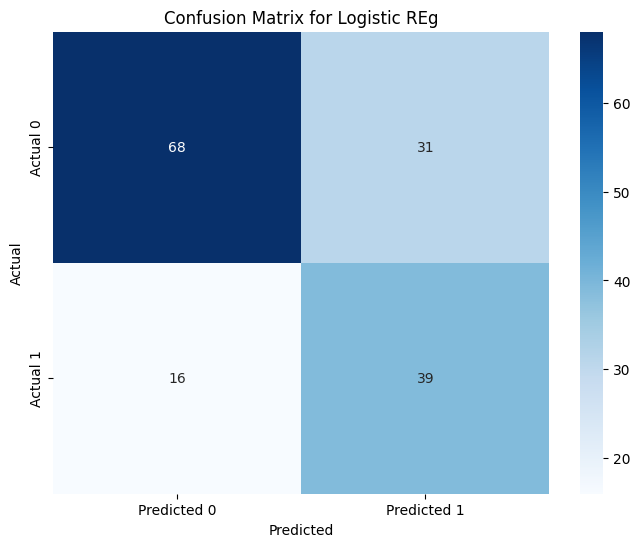

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_test_pred = lr_model.predict(X_test)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, lr_test_pred)}")
testing_accuracy.append(accuracy_score(y_test, lr_test_pred))
training_accuracy.append(accuracy_score(y_train, lr_model.predict(X_train)))
model_name.append('Logistic Regression')

precision.append(precision_score(y_test, lr_test_pred))
recall.append(recall_score(y_test, lr_test_pred))
f1.append(f1_score(y_test, lr_test_pred))
roc_auc.append(roc_auc_score(y_test, lr_test_pred))
cm = confusion_matrix(y_test, lr_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for Logistic REg')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KNN Test Accuracy: 0.6883116883116883


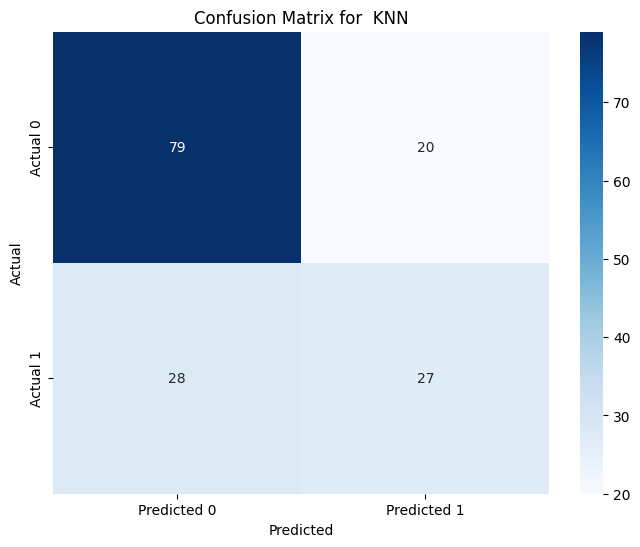

In [ ]:
# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_test_pred = knn_model.predict(X_test)
print(f"KNN Test Accuracy: {accuracy_score(y_test, knn_test_pred)}")
testing_accuracy.append(accuracy_score(y_test, knn_test_pred))
model_name.append('KNN')
training_accuracy.append(accuracy_score(y_train, knn_model.predict(X_train)))
precision.append(precision_score(y_test, knn_test_pred))
recall.append(recall_score(y_test, knn_test_pred))
f1.append(f1_score(y_test, knn_test_pred))
roc_auc.append(roc_auc_score(y_test, knn_test_pred))
cm= confusion_matrix(y_test, knn_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for  KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


SVM Test Accuracy: 0.7597402597402597


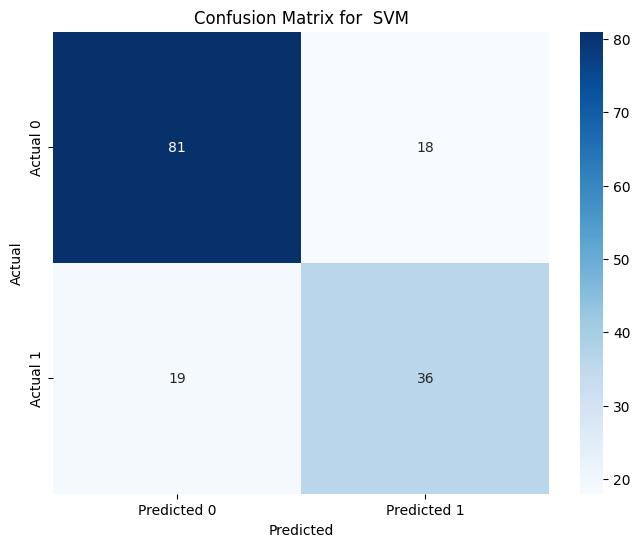

In [ ]:
# SVM
svm_model = SVC(kernel='linear')  # You can choose different kernels like 'rbf', 'poly', etc.
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print(f"SVM Test Accuracy: {accuracy_score(y_test, svm_pred)}")
testing_accuracy.append(accuracy_score(y_test, svm_pred))
training_accuracy.append(accuracy_score(y_train, svm_model.predict(X_train)))
model_name.append('SVM')
precision.append(precision_score(y_test, svm_pred))
recall.append(recall_score(y_test, svm_pred))
f1.append(f1_score(y_test, svm_pred))
roc_auc.append(roc_auc_score(y_test, svm_pred))
cm= confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for  SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# # Decision Tree
# dt_model = DecisionTreeClassifier(random_state=42)
# dt_model.fit(X_train, y_train)
# dt_pred = dt_model.predict(X_test)
# print(f"Decision Tree Test Accuracy: {accuracy_score(y_test, dt_pred)}")
# testing_accuracy.append(accuracy_score(y_test, dt_pred))

XGBoost Test Accuracy: 0.7077922077922078


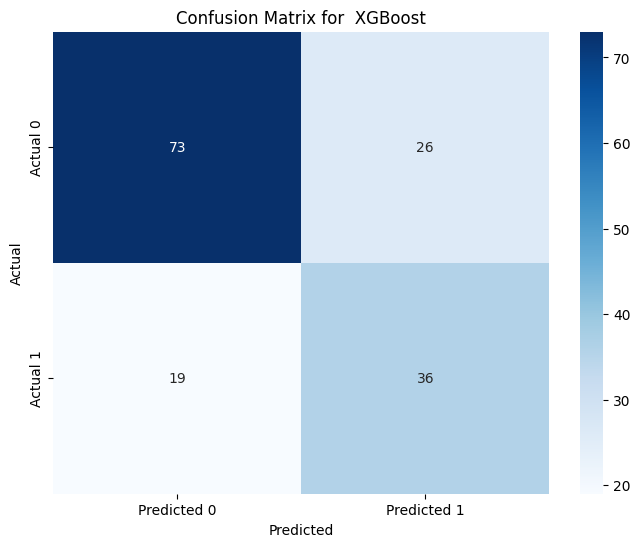

In [ ]:
# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_test_pred = xgb_model.predict(X_test)
print(f"XGBoost Test Accuracy: {accuracy_score(y_test, xgb_test_pred)}")
testing_accuracy.append(accuracy_score(y_test, xgb_test_pred))
training_accuracy.append(accuracy_score(y_train, xgb_model.predict(X_train)))
model_name.append('XGBoost')
precision.append(precision_score(y_test, xgb_test_pred))
recall.append(recall_score(y_test, xgb_test_pred))
f1.append(f1_score(y_test, xgb_test_pred))
roc_auc.append(roc_auc_score(y_test, xgb_test_pred))
cm= confusion_matrix(y_test, xgb_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for  XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Random Forest Test Accuracy: 0.7272727272727273


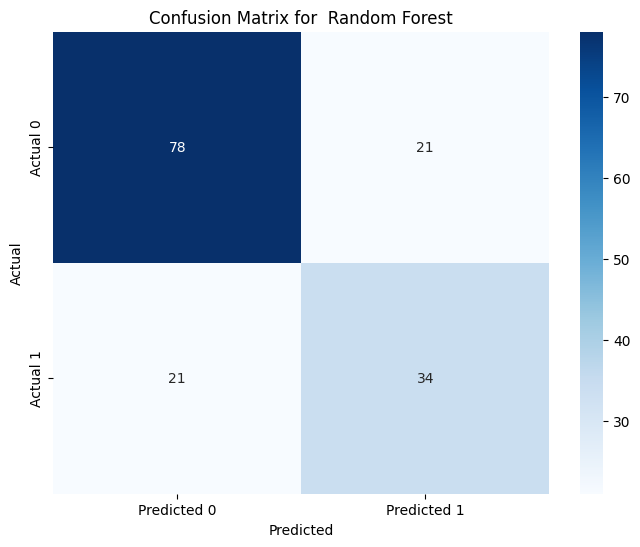

In [ ]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust n_estimators (number of trees)
rf_model.fit(X_train, y_train)
rf_test_pred = rf_model.predict(X_test)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, rf_test_pred)}")
testing_accuracy.append(accuracy_score(y_test, rf_test_pred))
training_accuracy.append(accuracy_score(y_train, rf_model.predict(X_train)))
model_name.append('Random Forest')
precision.append(precision_score(y_test, rf_test_pred))
recall.append(recall_score(y_test, rf_test_pred))
f1.append(f1_score(y_test, rf_test_pred))
roc_auc.append(roc_auc_score(y_test, rf_test_pred))
cm= confusion_matrix(y_test, rf_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for  Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:

from sklearn.metrics import confusion_matrix



cm = confusion_matrix(y_test, rf_pred)
print(cm)
print(precision_score(y_test, rf_pred))
print(recall_score(y_test, rf_pred))
print(f1_score(y_test, rf_pred))

[[78 21]
 [21 34]]
0.6181818181818182
0.6181818181818182
0.6181818181818182


Voting Ensemble (XGBoost + SVM) test Accuracy: 0.7468


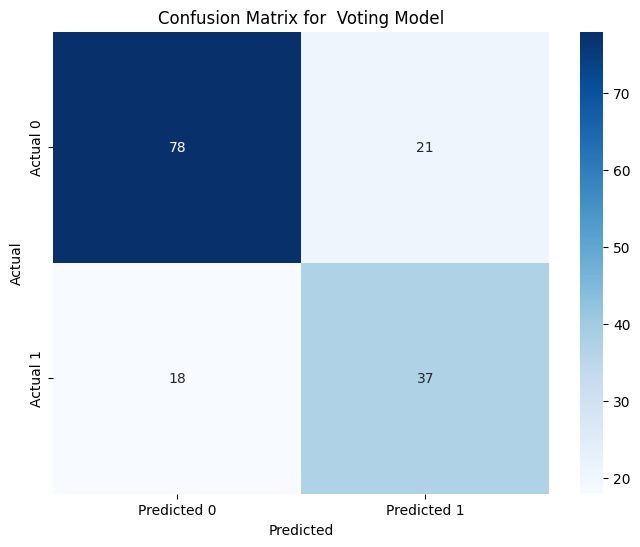

In [ ]:
#Ensemble  Model(XGBoost+SVM)
# Define the SVM model with probability=True
svm_model = SVC(kernel='linear', probability=True)  # Enable probability estimates


# Define the voting ensemble
voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('svm', svm_model)],
    voting='soft'  # Use 'soft' voting to average predicted probabilities
)


# Train the voting model
voting_model.fit(X_train, y_train)
# Calculate and print training accuracy
voting_test_pred = voting_model.predict(X_test)
voting_test_accuracy = accuracy_score(y_test, voting_test_pred)
print(f"Voting Ensemble (XGBoost + SVM) test Accuracy: {voting_test_accuracy:.4f}")
model_name.append('Voting Ensemble (XGBoost + SVM)')
testing_accuracy.append(voting_test_accuracy)
training_accuracy.append(accuracy_score(y_train, voting_model.predict(X_train)))
precision.append(precision_score(y_test, voting_test_pred))
recall.append(recall_score(y_test, voting_test_pred))
f1.append(f1_score(y_test, voting_test_pred))
roc_auc.append(roc_auc_score(y_test, voting_test_pred))
cm= confusion_matrix(y_test, voting_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for  Voting Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()






Hybrid (GB + SVM) test Accuracy: 0.7403


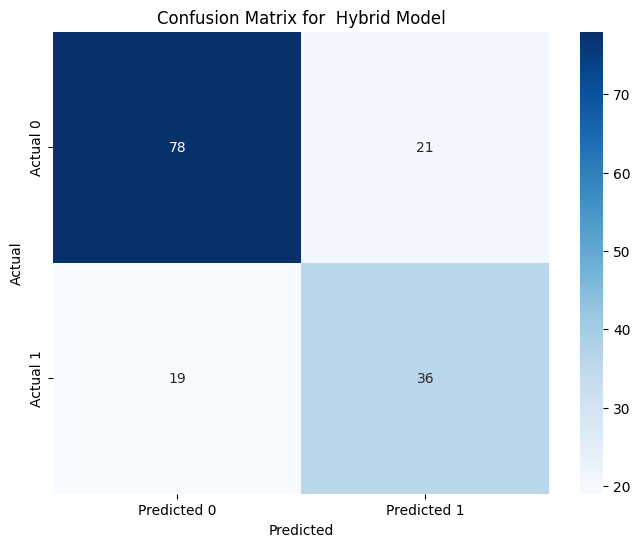

In [ ]:
#Hybrid Model(XGBoost+SVM)
# Train a Gradient Boosting model first
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)


# Use the predictions of the Gradient Boosting model as features for SVM
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)


# Stacking Gradient Boosting predictions into the original features
X_train_hybrid = np.column_stack((X_train, gb_train_pred))
X_test_hybrid = np.column_stack((X_test, gb_test_pred))


# Train an SVM model on this new dataset
svm_hybrid_model = SVC()
svm_hybrid_model.fit(X_train_hybrid, y_train)


# Make predictions using the hybrid model
svm_hybrid_pred = svm_hybrid_model.predict(X_test_hybrid)
# Hybrid (Gradient Boosting + SVM)

svm_hybrid_test_accuracy = accuracy_score(y_test, svm_hybrid_pred)
print(f"Hybrid (GB + SVM) test Accuracy: {svm_hybrid_test_accuracy:.4f}")
model_name.append('Hybrid (GB + SVM)')
testing_accuracy.append(svm_hybrid_test_accuracy)
training_accuracy.append(accuracy_score(y_train, svm_hybrid_model.predict(X_train_hybrid)))
precision.append(precision_score(y_test, svm_hybrid_pred))
recall.append(recall_score(y_test, svm_hybrid_pred))
f1.append(f1_score(y_test, svm_hybrid_pred))
roc_auc.append(roc_auc_score(y_test, svm_hybrid_pred))
cm= confusion_matrix(y_test, svm_hybrid_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
plt.title(f'Confusion Matrix for  Hybrid Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()







In [ ]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# #Logistic Regression
# lr_train_pred = lr_model.predict(X_train)
# lr_train_accuracy = accuracy_score(y_train, lr_train_pred)
# print(f"Logistic Regression Train Accuracy: {lr_train_accuracy:.4f}")
# model_name.append('Logistic Regression')
# training_accuracy.append(lr_train_accuracy)
# precision.append(precision_score(y_train, lr_train_pred))
# recall.append(recall_score(y_train, lr_train_pred))
# f1.append(f1_score(y_train, lr_train_pred))
# roc_auc.append(roc_auc_score(y_train, lr_train_pred))

# # lr_model = LogisticRegression() # Create an instance of the Logistic Regression model
# # lr_model.fit(X_train, y_train) # Train the model using your training data

# # # Logistic Regression
# # lr_train_pred = lr_model.predict(X_train)
# # lr_train_accuracy = accuracy_score(y_train, lr_train_pred)
# # print(f"Logistic Regression Train Accuracy: {lr_train_accuracy:.4f}")
# # model_name.append('Logistic Regression')
# # training_accuracy.append(lr_train_accuracy)
# # precision.append(precision_score(y_train, lr_train_pred))
# # recall.append(recall_score(y_train, lr_train_pred))
# # f1.append(f1_score(y_train, lr_train_pred))
# # roc_auc.append(roc_auc_score(y_train, lr_train_pred))



# #K-Nearest Neighbors
# knn_train_pred = knn_model.predict(X_train)
# knn_train_accuracy = accuracy_score(y_train, knn_train_pred)
# print(f"KNN Train Accuracy: {knn_train_accuracy:.4f}")
# model_name.append('KNN')
# training_accuracy.append(knn_train_accuracy)
# precision.append(precision_score(y_train, knn_train_pred))
# recall.append(recall_score(y_train, knn_train_pred))
# f1.append(f1_score(y_train, knn_train_pred))
# roc_auc.append(roc_auc_score(y_train, knn_train_pred))



# # SVM
# svm_model = SVC(kernel='linear', probability=True)  # Or your preferred SVC parameters
# svm_model.fit(X_train, y_train)

# svm_train_pred = svm_model.predict(X_train)
# svm_train_accuracy = accuracy_score(y_train, svm_train_pred)
# print(f"SVM Train Accuracy: {svm_train_accuracy:.4f}")
# model_name.append('SVM')
# training_accuracy.append(svm_train_accuracy)
# precision.append(precision_score(y_train, svm_train_pred))
# recall.append(recall_score(y_train, svm_train_pred))
# f1.append(f1_score(y_train, svm_train_pred))
# roc_auc.append(roc_auc_score(y_train, svm_train_pred))

# # # Decision Tree
# # dt_train_pred = dt_model.predict(X_train)
# # dt_train_accuracy = accuracy_score(y_train, dt_train_pred)
# # print(f"Decision Tree Train Accuracy: {dt_train_accuracy:.4f}")
# # model_name.append('Decision Tree')
# # training_accuracy.append(dt_train_accuracy)
# # precision.append(precision_score(y_train, dt_train_pred))
# # recall.append(recall_score(y_train, dt_train_pred))
# # f1.append(f1_score(y_train, dt_train_pred))
# # roc_auc.append(roc_auc_score(y_train, dt_train_pred))

# # XGBoost
# xgb_train_pred = xgb_model.predict(X_train)
# xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
# print(f"XGBoost Train Accuracy: {xgb_train_accuracy:.4f}")
# model_name.append('XGBoost')
# training_accuracy.append(xgb_train_accuracy)
# precision.append(precision_score(y_train, xgb_train_pred))
# recall.append(recall_score(y_train, xgb_train_pred))
# f1.append(f1_score(y_train, xgb_train_pred))
# roc_auc.append(roc_auc_score(y_train, xgb_train_pred))

# # Random Forest
# rf_train_pred = rf_model.predict(X_train)
# rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
# print(f"Random Forest Train Accuracy: {rf_train_accuracy:.4f}")
# model_name.append('Random Forest')
# training_accuracy.append(rf_train_accuracy)
# precision.append(precision_score(y_train, rf_train_pred))
# recall.append(recall_score(y_train, rf_train_pred))
# f1.append(f1_score(y_train, rf_train_pred))
# roc_auc.append(roc_auc_score(y_train, rf_train_pred))

# #Ensemble  Model(XGBoost+SVM)
# # Define the SVM model with probability=True
# svm_model = SVC(kernel='linear', probability=True)  # Enable probability estimates

# # Define the voting ensemble
# voting_model = VotingClassifier(
#     estimators=[('xgb', xgb_model), ('svm', svm_model)],
#     voting='soft'  # Use 'soft' voting to average predicted probabilities
# )

# # Train the voting model
# voting_model.fit(X_train, y_train)
# # Calculate and print training accuracy
# voting_train_pred = voting_model.predict(X_train)
# voting_train_accuracy = accuracy_score(y_train, voting_train_pred)
# print(f"Voting Ensemble (XGBoost + SVM) Train Accuracy: {voting_train_accuracy:.4f}")
# model_name.append('Voting Ensemble (XGBoost + SVM)')
# training_accuracy.append(voting_train_accuracy)
# precision.append(precision_score(y_train, voting_train_pred))
# recall.append(recall_score(y_train, voting_train_pred))
# f1.append(f1_score(y_train, voting_train_pred))
# roc_auc.append(roc_auc_score(y_train, voting_train_pred))

# #Hybrid Model(XGBoost+SVM)
# # Train a Gradient Boosting model first
# gb_model = GradientBoostingClassifier(random_state=42)
# gb_model.fit(X_train, y_train)

# # Use the predictions of the Gradient Boosting model as features for SVM
# gb_train_pred = gb_model.predict(X_train)
# gb_test_pred = gb_model.predict(X_test)

# # Stacking Gradient Boosting predictions into the original features
# X_train_hybrid = np.column_stack((X_train, gb_train_pred))
# X_test_hybrid = np.column_stack((X_test, gb_test_pred))

# # Train an SVM model on this new dataset
# svm_hybrid_model = SVC()
# svm_hybrid_model.fit(X_train_hybrid, y_train)

# # Make predictions using the hybrid model
# svm_hybrid_pred = svm_hybrid_model.predict(X_test_hybrid)
# # Hybrid (Gradient Boosting + SVM)
# svm_hybrid_pred = svm_hybrid_model.predict(X_train_hybrid)
# svm_hybrid_train_accuracy = accuracy_score(y_train, svm_hybrid_pred)
# print(f"Hybrid (GB + SVM) Train Accuracy: {svm_hybrid_train_accuracy:.4f}")
# model_name.append('Hybrid (GB + SVM)')
# training_accuracy.append(svm_hybrid_train_accuracy)
# precision.append(precision_score(y_train, svm_hybrid_pred))
# recall.append(recall_score(y_train, svm_hybrid_pred))
# f1.append(f1_score(y_train, svm_hybrid_pred))
# roc_auc.append(roc_auc_score(y_train, svm_hybrid_pred))


In [ ]:


# # Calculate and print testing accuracy
# voting_test_pred = voting_model.predict(X_test)
# voting_test_accuracy = accuracy_score(y_test, voting_test_pred)
# print(f"Voting Ensemble (XGBoost + SVM) Test Accuracy: {voting_test_accuracy:.4f}")
# testing_accuracy.append(voting_test_accuracy)


In [ ]:


# # Calculate and print testing accuracy
# svm_hybrid_pred_test = svm_hybrid_model.predict(X_test_hybrid)  # Assuming you have X_test_hybrid
# svm_hybrid_test_accuracy = accuracy_score(y_test, svm_hybrid_pred_test)
# print(f"Hybrid (GB + SVM) Test Accuracy: {svm_hybrid_test_accuracy:.4f}")
# testing_accuracy.append(svm_hybrid_test_accuracy)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report)

In [ ]:
X_test.shape

(154, 8)

# Train and Use Deep Neural Network (DNN) for Stacking

In [ ]:
from sklearn.neural_network import MLPClassifier



# Train a simple Deep Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42) # Increased max_iter to 1000
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np


columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, names=columns)

# Split data into features (X) and target (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define base models
base_learners = [
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss')),
    ('svc', SVC(probability=True, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
]

# Define meta-model
meta_model = LogisticRegression(random_state=42)

# Define Stacking Classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(X_train_scaled, y_train)

# Predictions on the test set
y_train_pred = stacking_model.predict(X_train_scaled)
y_test_pred = stacking_model.predict(X_test_scaled)




In [ ]:
# Evaluate performance
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
Precision_Score = precision_score(y_test, y_test_pred)
Recall = recall_score(y_test, y_test_pred)
F1 = f1_score(y_test, y_test_pred)
Roc_auc = roc_auc_score(y_test, y_test_pred)

# Print results
print("Stacking Model Performance (Best Accuracy):")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Precision: {Precision_Score:.4f}")
print(f"Recall: {Recall:.4f}")
print(f"F1 Score: {F1:.4f}")
print(f"ROC AUC Score: {Roc_auc:.4f}")

Stacking Model Performance (Best Accuracy):
Training Accuracy: 0.9814
Testing Accuracy: 0.7489
Precision: 0.6447
Recall: 0.6125
F1 Score: 0.6282
ROC AUC Score: 0.7168


In [ ]:
model_name.append('Stacking')
training_accuracy.append(train_accuracy)
testing_accuracy.append(test_accuracy)
precision.append(Precision_Score)
recall.append(Recall)
f1.append(F1)
roc_auc.append(Roc_auc)

In [ ]:
print(len(model_name))
print(len(training_accuracy))
print(len(testing_accuracy))
print(len(precision))
print(len(recall))
print(len(f1))
print(len(roc_auc))

8
8
8
8
8
8
8


In [ ]:
# prompt: show result in table highlighting best accuracy model

import pandas as pd

# Assuming 'model_name', 'training_accuracy', 'testing_accuracy', 'precision', 'recall', and 'f1' are already defined
# Create a DataFrame
results_df = pd.DataFrame({
    'Model': model_name,
    'Training Accuracy': training_accuracy,
    'Testing Accuracy': testing_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC AUC': roc_auc
})

# Sort the DataFrame by 'Testing Accuracy


results_df  = results_df .sort_values(by=['Testing Accuracy'], ascending=False)

(results_df [['Model', 'Training Accuracy','Testing Accuracy', 'Precision', 'Recall', 'F1 Score','ROC AUC']]
    .style
    .highlight_max(subset=['Training Accuracy','Testing Accuracy', 'Precision', 'Recall', 'F1 Score','ROC AUC'], color='lime', axis=0)
    .highlight_min(subset=['Training Accuracy','Testing Accuracy', 'Precision', 'Recall', 'F1 Score','ROC AUC'], color='tomato', axis=0))

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score,ROC AUC
2,SVM,0.771987,0.759740,0.666667,0.654545,0.660550,0.736364
0,Logistic Regression,0.770358,0.753247,0.649123,0.672727,0.660714,0.735354
7,Stacking,0.981378,0.748918,0.644737,0.612500,0.628205,0.716846
5,Voting Ensemble (XGBoost + SVM),0.988599,0.746753,0.637931,0.672727,0.654867,0.730303
6,Hybrid (GB + SVM),0.938111,0.740260,0.631579,0.654545,0.642857,0.721212
4,Random Forest,1.000000,0.727273,0.618182,0.618182,0.618182,0.703030
3,XGBoost,1.000000,0.707792,0.580645,0.654545,0.615385,0.695960
1,KNN,0.820847,0.688312,0.574468,0.490909,0.529412,0.644444


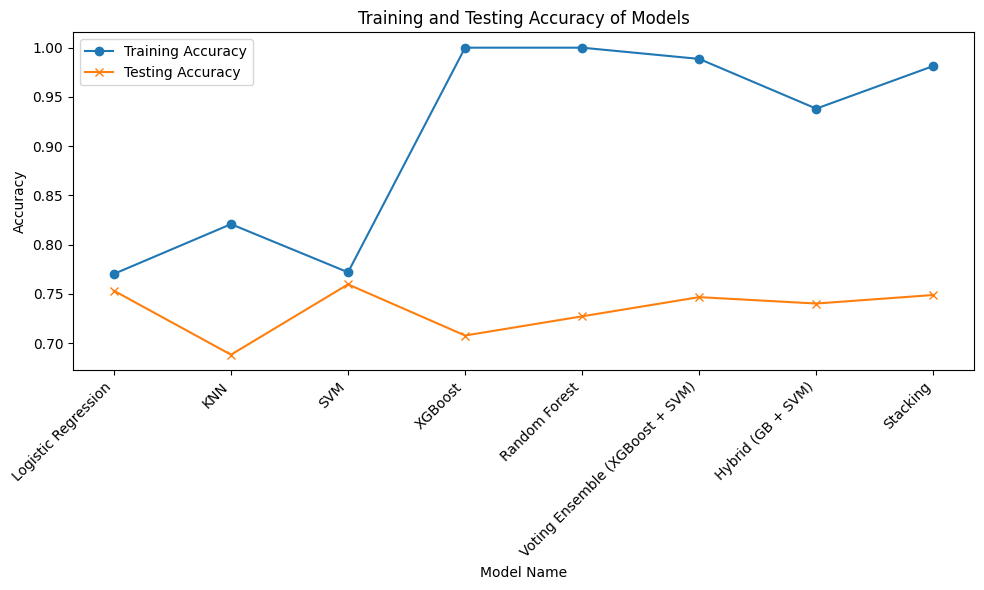

In [ ]:
# prompt:  plot line chart of training and testing accuracy make it ascending

import matplotlib.pyplot as plt

# Assuming 'model_name', 'training_accuracy', and 'testing_accuracy' are defined as in your provided code

plt.figure(figsize=(10, 6))
plt.plot(model_name, training_accuracy, label='Training Accuracy', marker='o')
plt.plot(model_name, testing_accuracy, label='Testing Accuracy', marker='x')
plt.xlabel("Model Name")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy of Models")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

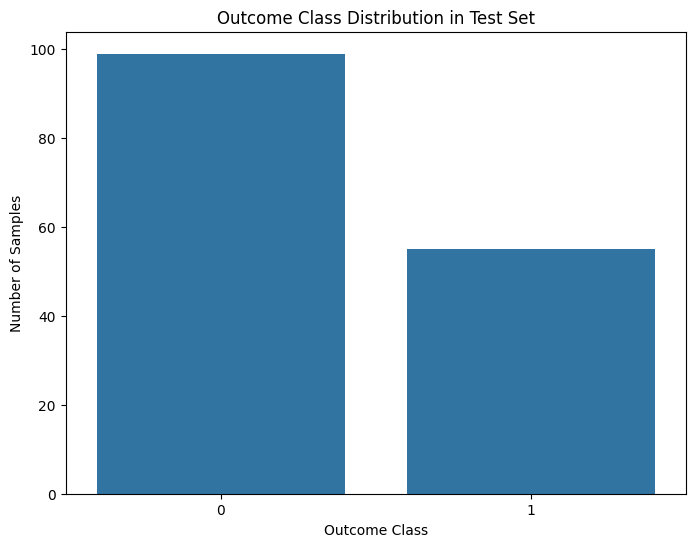

In [ ]:
# prompt: bar plot for outcome class

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'y_test' and 'rf_test_pred' are defined from your RandomForestClassifier
# Create the bar plot
plt.figure(figsize=(8, 6))
outcome_counts = pd.Series(y_test).value_counts()
sns.barplot(x=outcome_counts.index, y=outcome_counts.values)
plt.title("Outcome Class Distribution in Test Set")
plt.xlabel("Outcome Class")
plt.ylabel("Number of Samples")
plt.show()